#**BRAIN MODELING PROJECT - Lab2 Neuron Models**

Group members:


*   Gala Miladinović, 515653
*   Mina Miladinović, 515650
*   Gabriel Leguizamón, 513217

February 2026.

# Fitzhugh-Nagumo model:
It is a 2D model with two state variables:
- v(t): membrane potential;
- w(t): 'recovery' variable.

The pair of coupled first order equations of the model are:

$\frac{dv}{dt}=v-\frac{v^{3}}{3}-w+I_{ext}\\
\frac{dw}{dt}=\frac{1}{c}(v+a-bw)$

For the nullclines:

$\frac{dv}{dt}=0\\
\frac{dw}{dt}=0$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.integrate import odeint
import sympy as sp

In [ ]:
def default_pars(**kwargs):
    """
    Fix the dictionary of parameters of Fitzhugh-Nagumo model.
    """
    pars={}
    pars['a'] = 0.7
    pars['b'] = 0.8
    pars['c'] = 12.5
    pars['I_ext']=0.2

    return pars

## 1. Nullclines

In [ ]:
def fn_derivs(v,w,params):
    """
    Compute v and w derivates in the phase space (vector field).
    """
    dv_dt = v-v**3/3. - w+params['I_ext']
    dw_dt = (v+params['a']-params['b']*w)/params['c']
    return dv_dt,dw_dt

In [ ]:
def nullclines(params):
    """
    Compute nullclines for v and w.
    """
    x = np.linspace(-3.,3.,100)
    v_n = x - x**3/3. + params['I_ext']
    w_n = (x + params['a'])/params['b']
    return x,v_n,w_n

def compute_vector_field(params):
    """
    Compute vector field in the entire phase space to be shown.
    """
    grid = np.linspace(-3, 3, 80)
    v, w = np.meshgrid(grid, grid)
    dv_dt, dw_dt = fn_derivs(v,w,params)
    len_ = np.sqrt(dv_dt**2 + dw_dt**2)
    dv_norm = dv_dt / len_
    dw_norm = dw_dt / len_
    length = 0.1
    dv_scaled = dv_norm * length
    dw_scaled = dw_norm * length
    return v,w,dv_scaled, dw_scaled

def find_critical_point(params):
    """
    Solve the system of equations to find the intesection of nullclines.
    Return the coordinates of the critical point in the phase space.
    """
    x, y = sp.symbols('x y')
    eq1 = x - x**3/3. - y + params['I_ext']
    eq2 = x + params['a'] - params['b']*y
    c_p = sp.solve((eq1, eq2), (x, y))
    return c_p[0][0],c_p[0][1]

def plot_nullclines(I_ext):
    """
    Plot nullclines for different values of the parameters.
    """
    params=default_pars()
    params['I_ext']=I_ext
    x,v_n,w_n=nullclines(params)
    cp_x,cp_y = find_critical_point(params)
    v,w,dv_scaled,dw_scaled=compute_vector_field(params)
    n_skip = 2
    plt.figure(figsize=(8, 5))
    plt.title('Nullclines')
    plt.plot(x, v_n, label='v_nullcline')
    plt.plot(x, w_n, label='w_nullcline')
    plt.plot(cp_x,cp_y, 'r*', markersize=8,label='Critical point')
    plt.quiver(v[::n_skip, ::n_skip], w[::n_skip, ::n_skip],dv_scaled[::n_skip, ::n_skip],
               dw_scaled[::n_skip, ::n_skip],angles='xy', scale_units='xy', scale=1., facecolor='gray',width=0.002)
    plt.xlabel('v (membrane potential)')
    plt.ylabel('w (recovery variable)')
    plt.legend(loc='upper right')
    plt.xlim(-3,3)
    plt.ylim(-2,3)
    plt.grid(True)
    plt.show()


In [ ]:
_ = widgets.interact(plot_nullclines,I_ext=(0,2,0.2))

interactive(children=(FloatSlider(value=1.0, description='I_ext', max=2.0, step=0.2), Output()), _dom_classes=…

$I_{ext}$ effectively repositions the v-nullcline either upward or downward. Consequently, altering the value of
the external stimulus adjusts the placement of the critical point, causing it to fall on the left, middle, or right segment of the v-nullcline curve. The location of the critical point plays a pivotal role in shaping the dynamics of the membrane potential v.

## 2. Trajectories

In [ ]:
def fitzhugh_nagumo(x,t,params):
    """
    Differential equation of Fitzhugh-Nagumo model.
    x is the state vector (v,w) where v is the membrane potential and w is the recovery variable
    """
    dv_dt = x[0]-x[0]**3/3. - x[1]+params['I_ext']
    dw_dt = (x[0]+params['a']-params['b']*x[1])/params['c']

    return [dv_dt,dw_dt]

In [ ]:
def solve_fn(t,params,init_cond):
    """
    Find the numerical solution for the evolution over time of the state variables v and w.
    """
    x = odeint(fitzhugh_nagumo,init_cond,t,args=(params,))
    v, w = x.T
    return v,w

In [ ]:
def plot_results(t,init_cond,v,w):
    """
    Plot the resulting timeseries of v and w and plot v vs w in the phase plane.
    """

    plt.figure(figsize=(6, 4))
    plt.title('Phase plane')
    plt.plot(v,w,color='green',label='Trajectory')
    plt.plot(init_cond[0],init_cond[1], 'o',color='r', label=f'[$v_0$,$w_0$]')
    plt.xlabel('v (membrane potential)')
    plt.ylabel('w (recovery variable)')
    plt.xlim(-3,3)
    plt.ylim(-3,3)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.title('Timeseries')
    plt.plot(t, v, label='v(t)')
    plt.plot(t, w, label='w(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('State variables')
    plt.legend()
    plt.grid(True)
    plt.show()

def interactive_plot(v0,w0,I_ext):
    """
    Plot trajectories for different initial conditions and different I_ext.
    """
    params = default_pars()
    params['I_ext'] = I_ext
    init_cond = [v0,w0]
    t = np.linspace(0,200,num=2000)
    v,w = solve_fn(t,params,init_cond)
    plot_results(t,init_cond,v,w)


Look at how the spiking activity changes based on different trajectory kinds (stable point or limit cycle).

In [ ]:
_ = widgets.interact(interactive_plot, v0 = (-3, 3, .2), w0 = (-2,3,0.1), I_ext = (-1,2,0.05))

interactive(children=(FloatSlider(value=0.0, description='v0', max=3.0, min=-3.0, step=0.2), FloatSlider(value…

## 3. Characterize the dynamics
The dynamics changes based on the position of the critical point in the phase space, which is linked to the externali input value.

In [ ]:
def plot_all(x,v_n,w_n,cp_x,cp_y,v,w,v_,w_,dv_scaled,dw_scaled,init_cond,t,I_ext):
    """
    Plot all the necessary information for the dynamical analysis of the model.
    """

    n_skip=2
    plt.figure(figsize=(10, 6))
    plt.title('Phase plane for $I_{ext}=$'+ str(I_ext))
    plt.axvspan(-3, -1, color='blue', alpha=0.4, label='Region 1')
    plt.axvspan(-1, 1, color='orange', alpha=0.4, label='Region 2')
    plt.axvspan(1, 3, color='purple', alpha=0.4, label='Region 3')
    plt.plot(v,w,color='green',label='Trajectory')
    plt.plot(init_cond[0],init_cond[1], 'o',color='yellow', label=f'[$v_0$,$w_0$]')
    plt.plot(x, v_n, label='v_nullcline',alpha=0.3)
    plt.plot(x, w_n, label='w_nullcline',alpha=0.3)
    plt.plot(cp_x,cp_y, 'r*', markersize=8,label='Critical point')
    plt.quiver(v_[::n_skip, ::n_skip], w_[::n_skip, ::n_skip],dv_scaled[::n_skip, ::n_skip],
               dw_scaled[::n_skip, ::n_skip],angles='xy', scale_units='xy', scale=1., facecolor='gray',width=0.001)
    plt.xlabel('v (membrane potential)')
    plt.ylabel('w (recovery variable)')
    plt.xlabel('v (membrane potential)')
    plt.ylabel('w (recovery variable)')
    plt.xlim(-3,3)
    plt.ylim(-3,3)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.title('Timeseries for $I_{ext}=$'+ str(I_ext))
    plt.plot(t, v, label='v(t)')
    plt.plot(t, w, label='w(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('State variables')
    plt.legend()
    plt.grid(True)
    plt.show()


### 3.1 Small external stimulus currents: $0 \leq I_{ext} \leq 0.324 $
The critical point is Region 1 and it is a stable attractive fixed point. The response to weak stimuli corresponds to **subthreshold oscillation**.

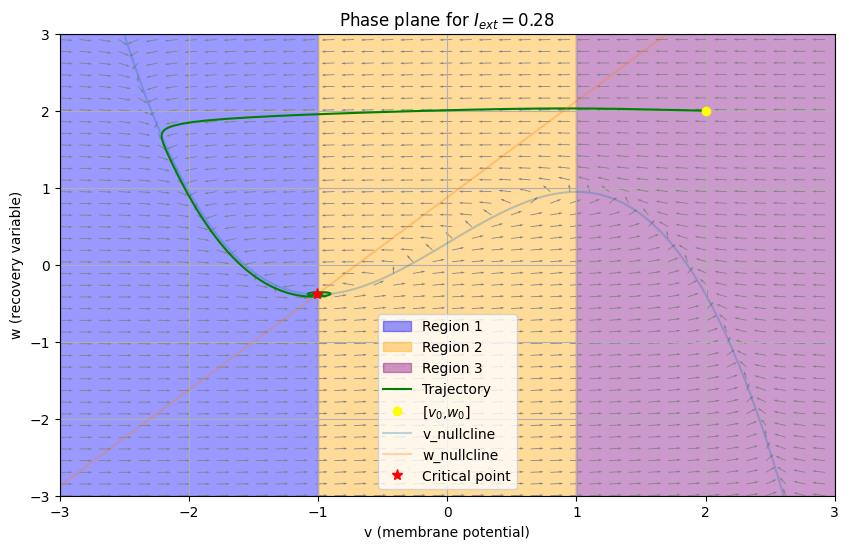

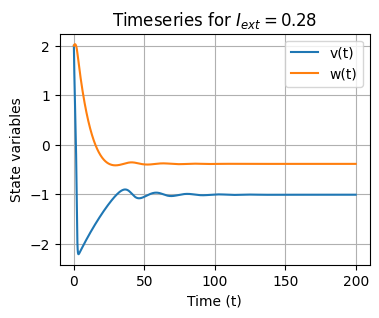

In [ ]:
params= default_pars()
params['I_ext'] = 0.28
init_cond = [2,2]
x,v_n,w_n=nullclines(params)
cp_x,cp_y = find_critical_point(params)
t = np.linspace(0,200,num=2000)
v,w = solve_fn(t,params,init_cond)
v_,w_,dv_scaled,dw_scaled=compute_vector_field(params)
plot_all(x,v_n,w_n,cp_x,cp_y,v,w,v_,w_,dv_scaled,dw_scaled,init_cond,t,params['I_ext'])

### 3.2 Intermediate external stimulus current: $0.325 \leq I_{ext} \leq 1.42$
The critical point is in Region 2 and it is associated to a limit cycle. In this case, a suprathreshold response is generated, with neuron spiking repetitevely (**tonic spiking**).

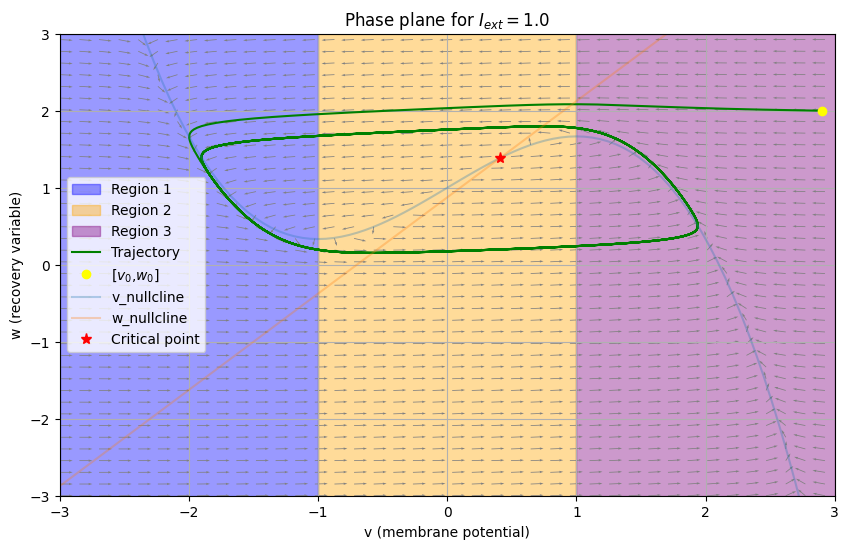

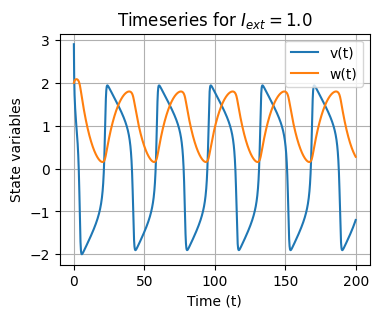

In [ ]:
params= default_pars()
params['I_ext'] = 1. # 0.350
init_cond = [2.9,2]
x,v_n,w_n=nullclines(params)
cp_x,cp_y = find_critical_point(params)
t = np.linspace(0,200,num=2000)
v,w = solve_fn(t,params,init_cond)
v_,w_,dv_scaled,dw_scaled=compute_vector_field(params)
plot_all(x,v_n,w_n,cp_x,cp_y,v,w,v_,w_,dv_scaled,dw_scaled,init_cond,t,params['I_ext'])

### 3.3 Large external stimulus currents: $I_{ext} > 1.42$
The critical point is in Region 3 and no action potentials are generated (**excitation block phenomenon**).

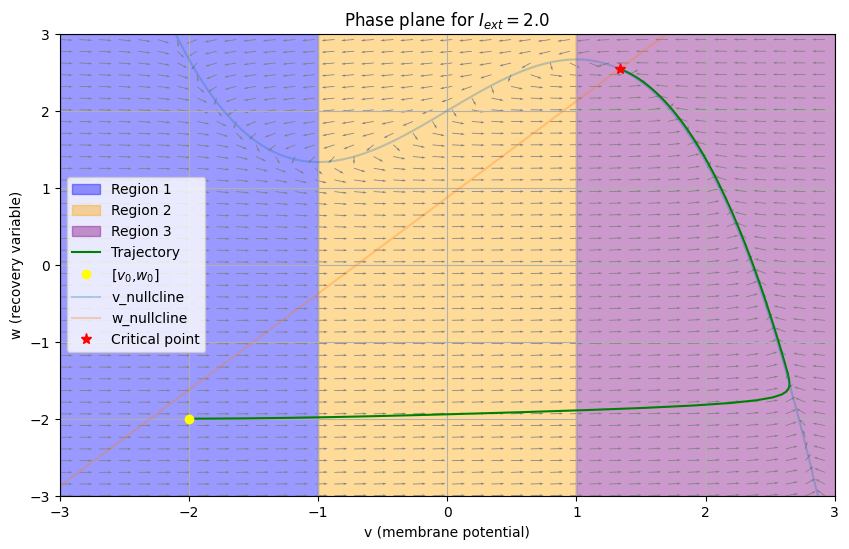

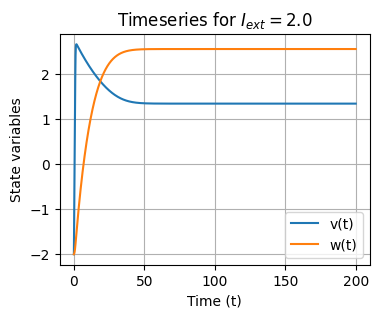

In [ ]:
params= default_pars()
params['I_ext'] = 2.0 # 1.4
init_cond = [-2,-2]
x,v_n,w_n=nullclines(params)
cp_x,cp_y = find_critical_point(params)
t = np.linspace(0,200,num=2000)
v,w = solve_fn(t,params,init_cond)
v_,w_,dv_scaled,dw_scaled=compute_vector_field(params)
plot_all(x,v_n,w_n,cp_x,cp_y,v,w,v_,w_,dv_scaled,dw_scaled,init_cond,t,params['I_ext'])

### 3.4 Negative external stimulus currents: $I_{ext} < 0 $

There is an attractive stable point in Region 1. The neuron fires a transient spike and then returns to the resting state; this dynamics can be associated to the phenomenon of post-inhibitory (rebound) spikes, called **anodal break excitation**.


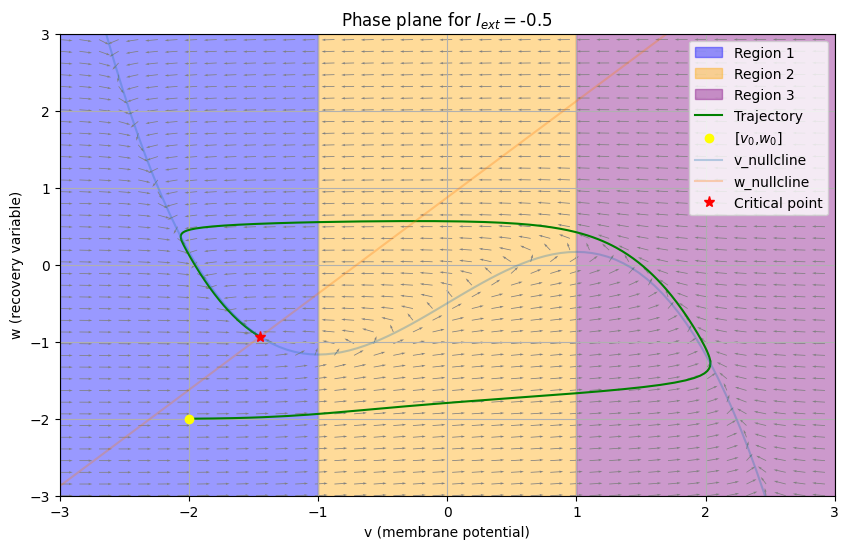

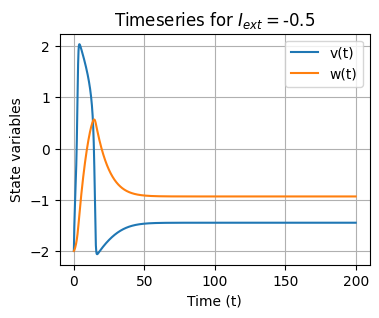

In [ ]:
params= default_pars()
params['I_ext'] = -0.5
init_cond = [-2,-2]
x,v_n,w_n=nullclines(params)
cp_x,cp_y = find_critical_point(params)
t = np.linspace(0,200,num=2000)
v,w = solve_fn(t,params,init_cond)
v_,w_,dv_scaled,dw_scaled=compute_vector_field(params)
plot_all(x,v_n,w_n,cp_x,cp_y,v,w,v_,w_,dv_scaled,dw_scaled,init_cond,t,params['I_ext'])

## 4. Response to time-dependent external stimuli $I_{ext}(t)$ - Spike accomodation

Look at how the neuron behaviour changes given an input that increases slowy or a faster one.

In [ ]:
def fitzhugh_nagumo_I_slow(x,t,params,a):
    """
    Differential equation of Fitzhugh-Nagumo model (slow external input).
    x is the state vector (v,w) where v is the membrane potential and w is the recovery variable
    """
    dv_dt = x[0]-x[0]**3/3. - x[1] + a * t
    dw_dt = (x[0]+params['a']-params['b']*x[1])/params['c']
    return [dv_dt,dw_dt]

def fitzhugh_nagumo_I_fast(x,t,params):
    """
    Differential equation of Fitzhugh-Nagumo model (fast external input).
    x is the state vector (v,w) where v is the membrane potential and w is the recovery variable
    """
    if (t<50 or t>55):
        dv_dt = x[0]-x[0]**3/3. - x[1]
    else:
        dv_dt = x[0]-x[0]**3/3. - x[1] + 0.5
    dw_dt = (x[0]+params['a']-params['b']*x[1])/params['c']
    return [dv_dt,dw_dt]

def solve_fn_I_slow(t,params,init_cond,a):
    """
    Find the numerical solution for the evolution over time of the state variables v and w (slow external input).
    """
    x = odeint(fitzhugh_nagumo_I_slow,init_cond,t,args=(params,a))
    v, w = x.T
    return v,w

def solve_fn_I_fast(t,params,init_cond):
    """
    Find the numerical solution for the evolution over time of the state variables v and w (fast external input).
    """
    x = odeint(fitzhugh_nagumo_I_fast,init_cond,t,args=(params,))
    v, w = x.T
    return v,w

In [ ]:
def plot_I_t(x,v_n,w_n,v,w,init_cond,t):
    """
    Plot nullclines, trajectory and timeseries.
    """

    n_skip=2
    plt.figure(figsize=(6, 6))
    plt.title('Phase plane for time-dependent $I_{ext}$')
    plt.plot(v,w,color='green',label='Trajectory')
    plt.plot(init_cond[0],init_cond[1], 'o',color='yellow', label=f'[$v_0$,$w_0$]')
    plt.plot(x, v_n, label='v_nullcline',alpha=0.3)
    plt.plot(x, w_n, label='w_nullcline',alpha=0.3)
    plt.ylabel('w (recovery variable)')
    plt.xlabel('v (membrane potential)')
    plt.ylabel('w (recovery variable)')
    plt.xlim(-3,3)
    plt.ylim(-3,3)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(4, 3))
    plt.title('Timeseries for for time-dependent $I_{ext}$')
    plt.plot(t, v, label='v(t)')
    plt.plot(t, w, label='w(t)')
    plt.xlabel('Time (t)')
    plt.ylabel('State variables')
    plt.xlim(0,220)
    plt.legend()
    plt.grid(True)
    plt.show()


### 4.1 $I_{ext}$ slowly increasing: $I_{ext} = 0.003t$
The model's resting equilibrium gradually shifts to the right, and the system's state smoothly tracks this shift without generating spikes until the current stimulus induces **repetitive spiking** in the neuron.

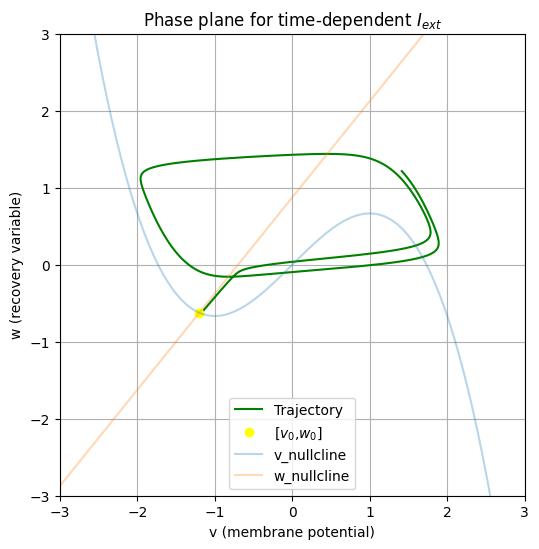

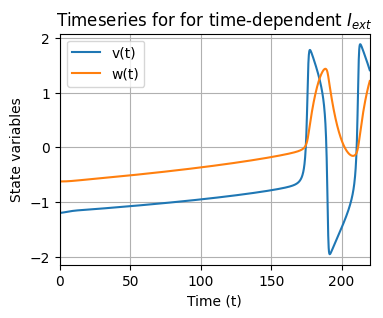

In [ ]:
params = default_pars()
init_cond = [-1.19940803524404 ,-0.624260044055044]
a = 0.003
t = np.linspace(0,220,num=2000)
params['I_ext']=-0.
v,w = solve_fn_I_slow(t,params,init_cond,a)
x,v_n,w_n=nullclines(params)
plot_I_t(x,v_n,w_n,v,w,init_cond,t)

### 4.2 $I_{ext}$ fastly increasing:
$I_{ext} = 0$,  for $t<50$ and $t>55$

$I_{ext} = 0.5$,  for $50<t<55$

Even with low-intensity steps, the trajectory cannot reach the new resting state but instead generates a **transient spike**.


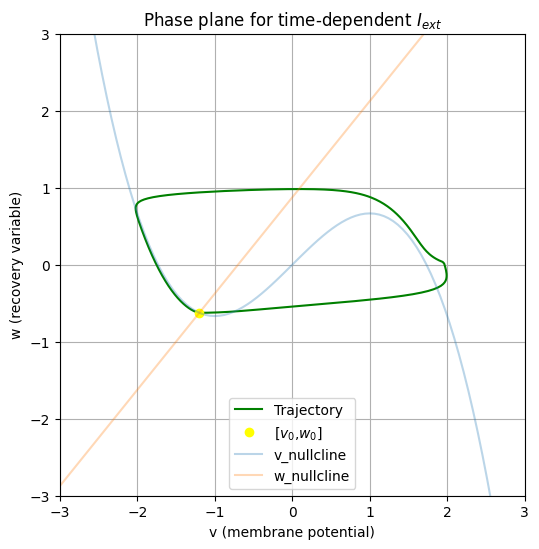

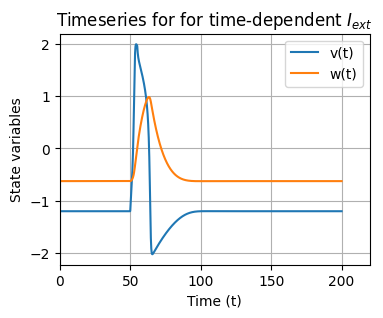

In [ ]:
params = default_pars()
init_cond = [-1.19940803524404 ,-0.624260044055044]
t = np.linspace(0,200,num=2000)
params['I_ext']=-0.
v,w = solve_fn_I_fast(t,params,init_cond)
x,v_n,w_n=nullclines(params)
plot_I_t(x,v_n,w_n,v,w,init_cond,t)


## 5. Extensions: equilibria, stability, modern solver, and f–I curve

- Compute all equilibrium points (nullcline intersections) for a given parameter set
- Compute the Jacobian and eigenvalues at equilibria to classify stability
- Use a modern integrator (`solve_ivp`) with clean support for time-varying input currents
- Sweep $I_{ext}$ to produce an **f–I curve** (firing rate vs input current)


In [ ]:
from scipy.integrate import solve_ivp


In [ ]:
def equilibria(params, tol_imag=1e-10):
    """Equilibrium points for a given parameter set."""
    a, b, I = params['a'], params['b'], params['I_ext']
    coeffs = [b, 0.0, (3 - 3*b), (3*a - 3*b*I)]
    roots = np.roots(coeffs)

    eq_points = []
    for r in roots:
        if abs(r.imag) < tol_imag:
            v_star = float(r.real)
            w_star = (v_star + a)/b
            eq_points.append((v_star, w_star))
    # sort for consistent display
    eq_points.sort(key=lambda p: p[0])
    return eq_points


def jacobian_fhn(v, w, params):
    """Jacobian of the FHN vector field at (v, w)."""
    b, c = params['b'], params['c']
    return np.array([
        [1 - v**2,   -1],
        [1/c,     -b/c]
    ], dtype=float)


def classify_equilibrium(eigs, eps=1e-8):
    """Rough classification based on eigenvalues."""
    reals = np.real(eigs)

    if np.all(reals < -eps):
        # stable
        if np.any(np.abs(np.imag(eigs)) > eps):
            return "stable spiral"
        return "stable node"
    if np.all(reals > eps):
        if np.any(np.abs(np.imag(eigs)) > eps):
            return "unstable spiral"
        return "unstable node"
    if np.any(reals > eps) and np.any(reals < -eps):
        return "saddle"
    return "near-neutral / borderline"


def print_equilibrium_report(params):
    eqs = equilibria(params)
    if not eqs:
        print("No real equilibria found (unexpected for standard FHN).")
        return

    print(f"Found {len(eqs)} equilibrium point(s) for I_ext={params['I_ext']:.3f}:")
    for k, (v_star, w_star) in enumerate(eqs, start=1):
        J = jacobian_fhn(v_star, w_star, params)
        eigs = np.linalg.eigvals(J)
        cls = classify_equilibrium(eigs)
        print(f"  {k}) (v*, w*) = ({v_star:.6f}, {w_star:.6f})")
        print(f"     eigenvalues: {eigs[0]:.6g}, {eigs[1]:.6g}  ->  {cls}")


In [ ]:
# Start from defaults, then tweak
params = default_pars(I_ext=0.2, a=0.7, b=0.8, c=12.5)

# Prints equilibria + eigenvalues + stability label
print_equilibrium_report(params)


Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral


For each input current, we compute the equilibrium and its eigenvalues to determine if the neuron is stable (rest) or unstable (spiking onset).

In [ ]:
# how stability changes with input
for I in [0.0, 0.2, 0.5, 0.8, 1.0]:
    params = default_pars(I_ext=I)
    print(f"\n=== I_ext = {I} ===")
    print_equilibrium_report(params)



=== I_ext = 0.0 ===
Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral

=== I_ext = 0.2 ===
Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral

=== I_ext = 0.5 ===
Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral

=== I_ext = 0.8 ===
Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral

=== I_ext = 1.0 ===
Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral


Phase-plane summary for FHN: plot vector field + nullclines + equilibrium stability (via Jacobian eigenvalues), and optionally overlay trajectories from chosen initial conditions to visualize attraction/oscillations.


In [ ]:
def plot_phase_plane_with_equilibria(params, xlim=(-3,3), ylim=(-2,3), grid=20,
                                     trajectories=None, tmax=200, dt=0.05):

    x = np.linspace(xlim[0], xlim[1], grid)
    y = np.linspace(ylim[0], ylim[1], grid)
    V, W = np.meshgrid(x, y)
    dV, dW = fn_derivs(V, W, params)

    L = np.sqrt(dV**2 + dW**2) + 1e-12
    dVn, dWn = dV/L, dW/L

    x_dense = np.linspace(xlim[0], xlim[1], 400)
    v_null = x_dense - x_dense**3/3 + params['I_ext']
    w_null = (x_dense + params['a'])/params['b']

    plt.figure(figsize=(7,5))
    plt.quiver(V, W, dVn, dWn, alpha=0.6)
    plt.plot(x_dense, v_null, label="dv/dt=0")
    plt.plot(x_dense, w_null, label="dw/dt=0")

    # equilibria
    eqs = equilibria(params)
    for (v_star, w_star) in eqs:
        eigs = np.linalg.eigvals(jacobian_fhn(v_star, w_star, params))
        cls = classify_equilibrium(eigs)
        plt.scatter([v_star], [w_star], s=60)
        plt.text(v_star+0.05, w_star+0.05, cls, fontsize=9)

    # trajectories (optional)
    if trajectories is not None:
        for init in trajectories:
            t, v, w = solve_fn_ivp((0, tmax), params, init, dt)
            plt.plot(v, w, 'k-', lw=1)

    plt.xlim(*xlim); plt.ylim(*ylim)
    plt.xlabel("v"); plt.ylabel("w")
    plt.legend()
    plt.show()


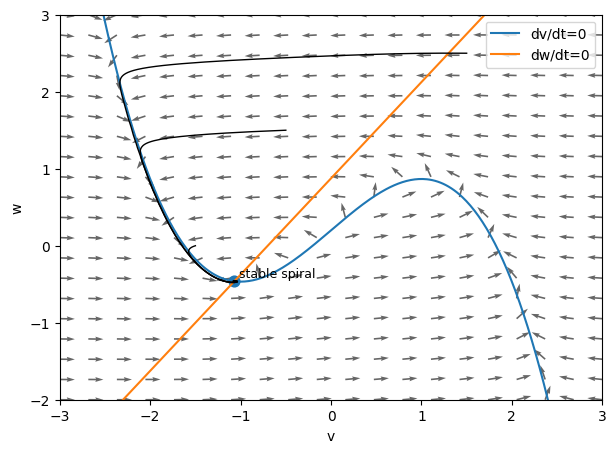

In [ ]:
from scipy.integrate import solve_ivp

def solve_fn_ivp(t_span, params, init_cond, dt=0.01, I_fn=None, method="RK45"):
    """Solve FHN with solve_ivp. Supports time-varying input via I_fn(t)."""
    def rhs(t, y):
        v, w = y
        a, b, c = params['a'], params['b'], params['c']
        I = params['I_ext'] if I_fn is None else float(I_fn(t))
        dv = v - v**3/3 - w + I
        dw = (v + a - b*w)/c
        return [dv, dw]

    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    sol = solve_ivp(rhs, t_span, init_cond, t_eval=t_eval, method=method)
    return sol.t, sol.y[0], sol.y[1]

plot_phase_plane_with_equilibria(
    params,
    trajectories=[(-1.5,0), (-0.5,1.5), (1.5,2.5)]
)


The step current turns repetitive firing on (limit cycle) between 50–250 ms, and when the current turns off the neuron stops spiking and relaxes back to rest.

A sufficient step current drives the system from a stable fixed point to a limit cycle (repetitive spiking), and removing the input restores the stable resting state.

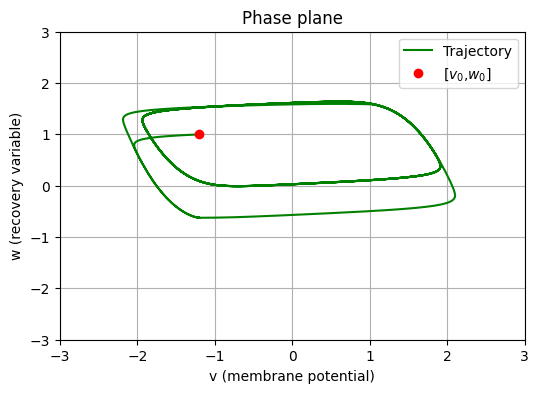

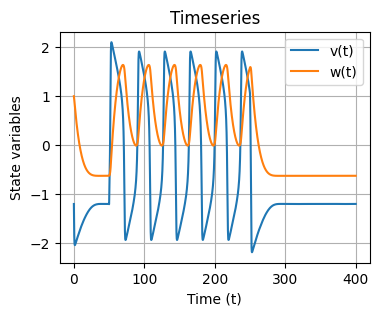

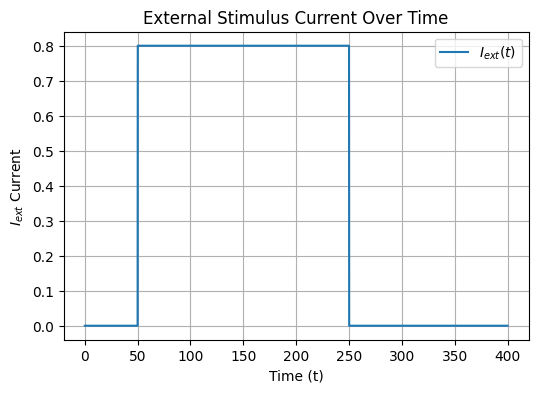

In [ ]:
params = default_pars(a=0.7, b=0.8, c=12.5)

def I_step(t):
    return 0.0 if (t < 50 or t > 250) else 0.8

init_cond=(-1.2, 1.0)
sol = solve_fn_ivp(
    t_span=(0, 400),
    params=params,
    init_cond=init_cond,
    dt=0.05,
    I_fn=I_step
)

t, v, w = sol
plot_results(t, init_cond, v, w)

plt.figure(figsize=(6, 4))
plt.plot(t, np.array([I_step(tt) for tt in t]), label='$I_{ext}(t)$')
plt.xlabel('Time (t)')
plt.ylabel('$I_{ext}$ Current')
plt.title('External Stimulus Current Over Time')
plt.legend()
plt.grid(True)
plt.show()

A sinusoidal input periodically pushes the neuron above and below the firing threshold, producing bursts of spikes during high input and silence during low input.

The neuron fires only when the oscillatory input exceeds threshold, creating stimulus-locked bursts of spikes and returning to rest when the input decreases.

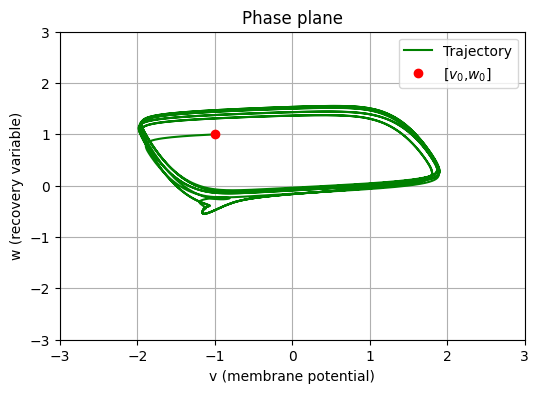

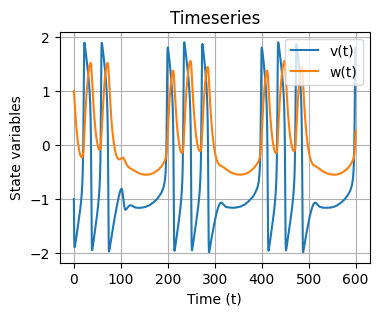

In [ ]:
params = default_pars()

def I_sine(t):
    return 0.4 + 0.3*np.sin(2*np.pi*(t/200.0))

init_cond=(-1.0, 1.0)
t, v, w = solve_fn_ivp(
    t_span=(0, 600),
    params=params,
    init_cond=init_cond,
    dt=0.05,
    I_fn=I_sine
)

plot_results(t, init_cond, v, w)


In [ ]:
def spike_times_from_v(t, v, thresh=1.0):
    """Detect upward threshold crossings; returns spike times (linear interpolation)."""
    v0, v1 = v[:-1], v[1:]
    up = (v0 < thresh) & (v1 >= thresh)
    idx = np.where(up)[0]

    ts = []
    for i in idx:
        # linear interpolate crossing time
        if v1[i] == v0[i]:
            ts.append(t[i])
        else:
            frac = (thresh - v0[i])/(v1[i] - v0[i])
            ts.append(t[i] + frac*(t[i+1]-t[i]))
    return np.array(ts)


def f_I_curve(I_values, base_params=None, init_cond=(-1.0, 1.0), t_total=400.0, t_transient=200.0, dt=0.05, thresh=1.0):
    """Compute firing rate (spikes per time unit) over a sweep of I_ext."""
    if base_params is None:
        base_params = default_pars()

    rates = []
    for I in I_values:
        params = dict(base_params)
        params['I_ext'] = float(I)
        t, v, w = solve_fn_ivp((0.0, t_total), params, init_cond, dt=dt)

        # discard transient
        mask = t >= t_transient
        t2, v2 = t[mask], v[mask]
        st = spike_times_from_v(t2, v2, thresh=thresh)

        duration = (t_total - t_transient)
        rate = len(st)/duration if duration > 0 else np.nan
        rates.append(rate)

    return np.array(rates)


The f–I curve shows that the neuron is silent below threshold and fires with increasing frequency as the input current increases.

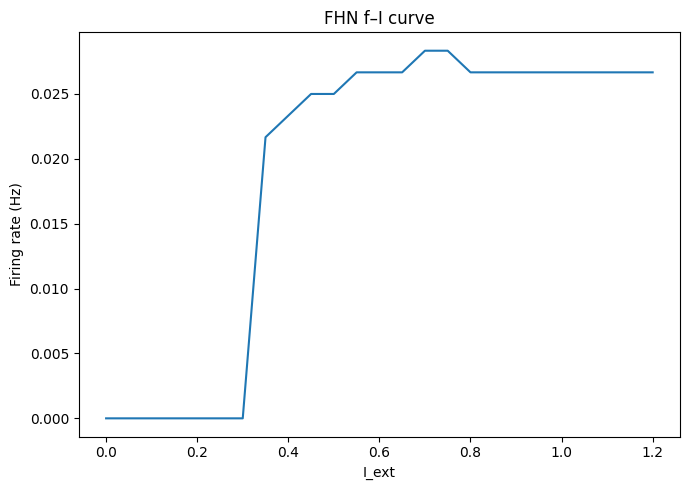

In [ ]:
params = default_pars(a=0.7, b=0.8, c=12.5)

I_values = np.linspace(0.0, 1.2, 25)

rates = f_I_curve(
    I_values=I_values,
    base_params=params,
    t_total=800,
    dt=0.05,
    init_cond=(-1.0, 1.0),
    t_transient=200,
    thresh=1.0
)

plt.figure(figsize=(7,5))
plt.plot(I_values, rates)
plt.xlabel("I_ext")
plt.ylabel("Firing rate (Hz)")
plt.title("FHN f–I curve")
plt.tight_layout()
plt.show()

Count threshold crossings to detect spikes and compute firing rate as spikes per second.

In [ ]:
spk_t = spike_times_from_v(t, v, thresh=1.0)

print("Number of spikes:", len(spk_t))
if len(spk_t) > 1:
    rate_hz = len(spk_t) / ((t[-1] - t[0]) / 1000.0)
    print("Approx firing rate (Hz):", rate_hz)


Number of spikes: 9
Approx firing rate (Hz): 15.0


# 6. Extensions: deeper dynamical-systems analysis

- Eigenvalues in the complex plane (stability visualization)
- Bifurcation-style diagram (min/max of v after transient vs I_ext)
- Basins / attraction via many initial conditions in the phase plane
- Limit-cycle period / frequency estimated from spike times


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_eigenvalues_complex(params):
    """Plot Jacobian eigenvalues (at each equilibrium) on the complex plane."""
    eqs = equilibria(params)
    if len(eqs) == 0:
        print("No equilibria found.")
        return

    plt.figure(figsize=(5,5))
    for (v_star, w_star) in eqs:
        eigs = np.linalg.eigvals(jacobian_fhn(v_star, w_star, params))
        plt.scatter(eigs.real, eigs.imag, s=80)
        cls = classify_equilibrium(eigs)
        plt.text(eigs.real.mean()+0.02, eigs.imag.mean()+0.02, cls, fontsize=9)

    plt.axhline(0)
    plt.axvline(0)
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.title(f"Eigenvalues at equilibria (I_ext={params['I_ext']:.2f})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def limit_cycle_stats(t, v, v_thresh=1.0):
    """Estimate spike times and mean period/frequency from v(t)."""
    spk = spike_times_from_v(t, v, v_thresh=v_thresh)
    if len(spk) < 2:
        return spk, None, 0.0
    periods = np.diff(np.array(spk))
    mean_period = float(periods.mean())
    freq_hz = 1000.0 / mean_period if mean_period > 0 else 0.0
    return spk, mean_period, float(freq_hz)

def bifurcation_minmax(I_values, params_base, init_cond=(-1.0, 1.0), tmax=800, dt=0.05, discard=200):
    """Bifurcation-style plot: steady-state min/max of v vs I_ext."""
    vmins, vmaxs = [], []
    for I in I_values:
        params = params_base.copy()
        params['I_ext'] = float(I)
        t, v, w = solve_fn_ivp((0, tmax), params, init_cond, dt=dt, I_fn=None)

        mask = t >= discard
        v_ss = v[mask]
        vmins.append(float(np.min(v_ss)))
        vmaxs.append(float(np.max(v_ss)))

    plt.figure(figsize=(7,5))
    plt.plot(I_values, vmins, '.', label='v min (steady)')
    plt.plot(I_values, vmaxs, '.', label='v max (steady)')
    plt.xlabel("I_ext")
    plt.ylabel("v")
    plt.title("Bifurcation-style diagram (min/max of v after transient)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_basins_trajectories(params, xlim=(-2.5,2.5), ylim=(-1.0,3.0),
                            grid_init=7, tmax=200, dt=0.05, alpha=0.35):
    """Draw many trajectories from a grid of initial conditions in phase plane."""
    xs = np.linspace(xlim[0], xlim[1], grid_init)
    ys = np.linspace(ylim[0], ylim[1], grid_init)

    plt.figure(figsize=(7,5))

    # vector field (normalized)
    x = np.linspace(xlim[0], xlim[1], 25)
    y = np.linspace(ylim[0], ylim[1], 25)
    V, W = np.meshgrid(x, y)
    dV, dW = fn_derivs(V, W, params)
    L = np.sqrt(dV**2 + dW**2) + 1e-12
    plt.quiver(V, W, dV/L, dW/L, alpha=0.5)

    # nullclines
    x_dense = np.linspace(xlim[0], xlim[1], 400)
    v_null = x_dense - x_dense**3/3 + params['I_ext']
    w_null = (x_dense + params['a'])/params['b']
    plt.plot(x_dense, v_null, label="dv/dt=0")
    plt.plot(x_dense, w_null, label="dw/dt=0")

    # equilibria
    eqs = equilibria(params)
    for (v_star, w_star) in eqs:
        eigs = np.linalg.eigvals(jacobian_fhn(v_star, w_star, params))
        cls = classify_equilibrium(eigs)
        plt.scatter([v_star], [w_star], s=60)
        plt.text(v_star+0.05, w_star+0.05, cls, fontsize=9)

    # trajectories
    for x0 in xs:
        for y0 in ys:
            t, v, w = solve_fn_ivp((0, tmax), params, (float(x0), float(y0)), dt=dt)
            plt.plot(v, w, 'k-', lw=1, alpha=alpha)

    plt.xlim(*xlim); plt.ylim(*ylim)
    plt.xlabel("v"); plt.ylabel("w")
    plt.title(f"Many trajectories (basins/attraction) | I_ext={params['I_ext']:.2f}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


## Example usage

The equilibrium is a stable spiral, meaning the neuron returns to rest with damped oscillations and does not spike at this input.

Found 1 equilibrium point(s) for I_ext=0.200:
  1) (v*, w*) = (-1.069392, -0.461740)
     eigenvalues: -0.1038+0.280029j, -0.1038-0.280029j  ->  stable spiral


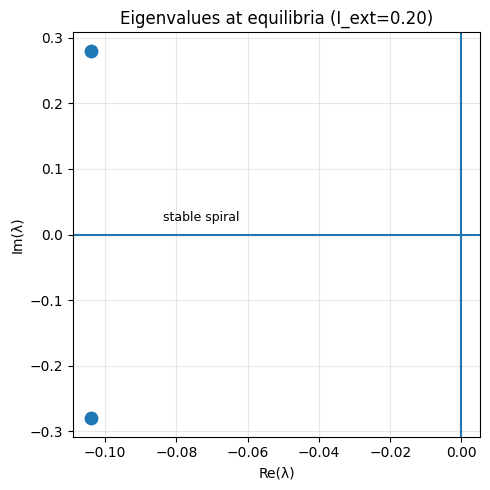

In [ ]:
# equilibrium report + eigenvalue plot
params = default_pars(I_ext=0.2)
print_equilibrium_report(params)
plot_eigenvalues_complex(params)


The split between min and max branches shows the transition from a stable fixed point (rest) to a limit cycle (spiking) as input current increases.

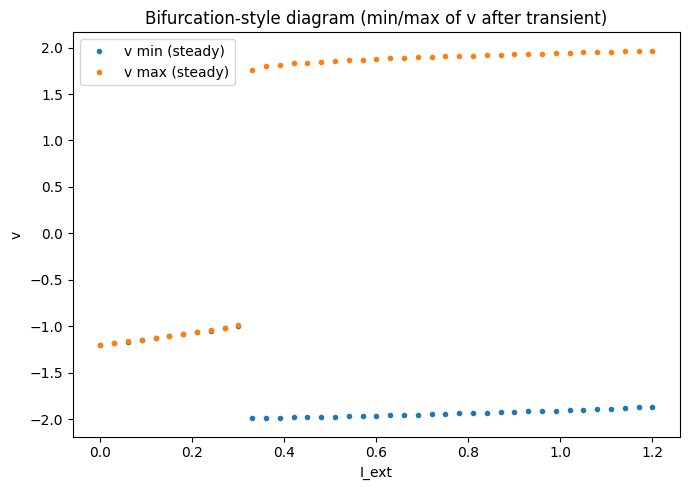

In [ ]:
# bifurcation-style min/max diagram
params_base = default_pars(a=0.7, b=0.8, c=12.5)

I_values = np.linspace(0.0, 1.2, 41)
bifurcation_minmax(I_values, params_base, init_cond=(-1.0, 1.0), tmax=900, dt=0.05, discard=250)


Plot many trajectories from different initial conditions to visualize basins of attraction. Shows whether all states converge to equilibrium or to a limit cycle.


All initial conditions end up at the same stable point, so the neuron is globally stable and does not spike for this input.

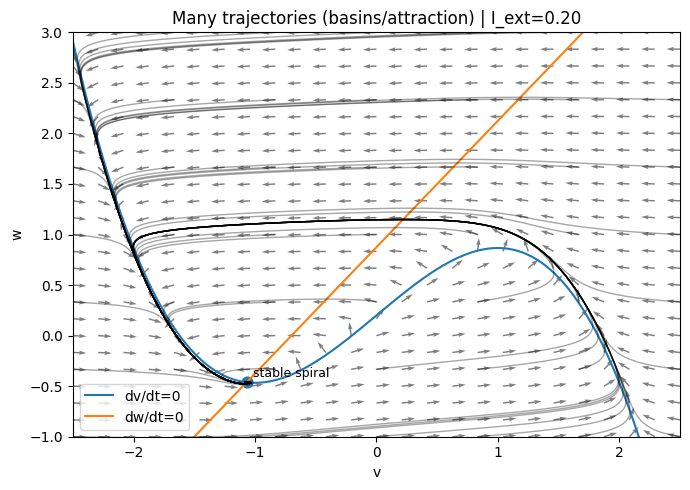

In [ ]:
# basins / attraction via many initial conditions
params = default_pars(I_ext=0.6)
plot_basins_trajectories(params, xlim=(-2.5,2.5), ylim=(-1.0,3.0), grid_init=7, tmax=200, dt=0.05)


Estimate firing rate from spike times: counts inter-spike intervals to compute mean period and frequency of the limit cycle.


In [ ]:
# limit-cycle period / frequency estimate from spike times
I_target = 0.8
params = default_pars()
params["I_ext"] = float(I_target)

t, v, w = solve_fn_ivp(
    t_span=(0, 800),
    params=params,
    init_cond=(-1.0, 1.0),
    dt=0.05,
    I_fn=None
)

print("I_ext used:", params["I_ext"])
print("v min/max:", float(v.min()), float(v.max()))

v_thresh = 1.0

if v.max() < v_thresh:
    print(f"No spikes: v(t) never crosses threshold {v_thresh}.")
    print("Spike count: 0")
    print("Mean period (ms): None")
    print("Frequency (Hz): 0.0")
else:
    spk = spike_times_from_v(t, v, thresh=v_thresh)

    transient_ms = 200
    spk = [tt for tt in spk if tt >= transient_ms]

    if len(spk) < 2:
        print("Spike count:", len(spk))
        print("Mean period (ms): None")
        print("Frequency (Hz): 0.0")
    else:
        periods = np.diff(np.array(spk))
        mean_T = float(periods.mean())
        f_hz = 1000.0 / mean_T if mean_T > 0 else 0.0

        print("Spike count:", len(spk))
        print("Mean period (ms):", mean_T)
        print("Frequency (Hz):", f_hz)


I_ext used: 0.8
v min/max: -1.9345181838862442 1.9122993136752533
Spike count: 16
Mean period (ms): 36.55624419641187
Frequency (Hz): 27.35510777932033
